# Task 1: Problem Definition & Success Metric

## Problem Definition

This is a binary classification problem where the goal is to predict whether an individual earns more than $50K per year. The positive class is income >50K, while the negative class is income <=50K.

## Business Objective

The business objective is to identify individuals who are likely to earn more than $50K per year so that marketing efforts can focus on higher-income customers and reduce wasted outreach.

## Class Base Rate

Positive class (>50K): 23.93%

Negative class (<=50K): 76.07%

## Primary Evaluation Metric

F1 score is selected as the primary evaluation metric because it balances precision and recall. Precision is important because false positives can lead to wasted outreach, while recall is important because we do not want to miss too many potential high-income customers.

## Stakeholder Summary

The goal is to predict which individuals are likely to earn more than $50K per year so that the business can focus its outreach on higher-income customers. We will use F1 score as the main measure of success because it balances identifying potential high-income customers with avoiding incorrect predictions. We will also monitor precision and recall to understand the trade-off between wasted outreach and missed opportunities.


In [18]:
from sklearn.datasets import fetch_openml
adult = fetch_openml('adult', version=2, as_frame=True)
df = adult.frame
display(df.head())
print(df.shape)
df.columns


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


(48842, 15)


Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'class'],
      dtype='str')

# Task 2

Dataset Shape: (48842, 15)

--- Data Types & Info ---
<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  int64   
dtypes: category(8), int64(7)
memory usage: 3.0 MB

--- Numerical 

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0
class,48842.0,0.239282,0.426649,0.0,0.0,0.0,0.0,1.0



--- Categorical Summary ---


,count,unique,top,freq
workclass,46043,8,Private,33906
education,48842,16,HS-grad,15784
marital-status,48842,7,Married-civ-spouse,22379
occupation,46033,14,Prof-specialty,6172
relationship,48842,6,Husband,19716
race,48842,5,White,41762
sex,48842,2,Male,32650
native-country,47985,41,United-States,43832


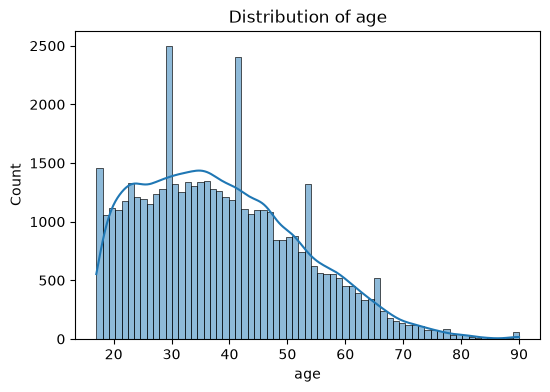

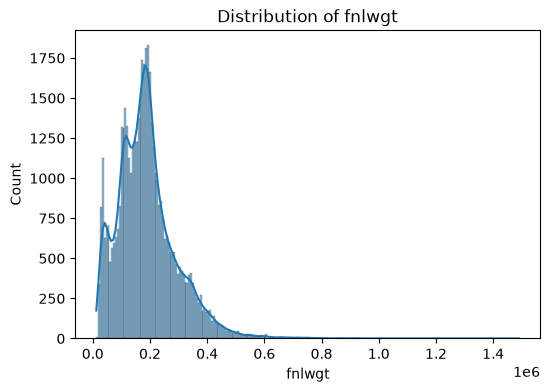

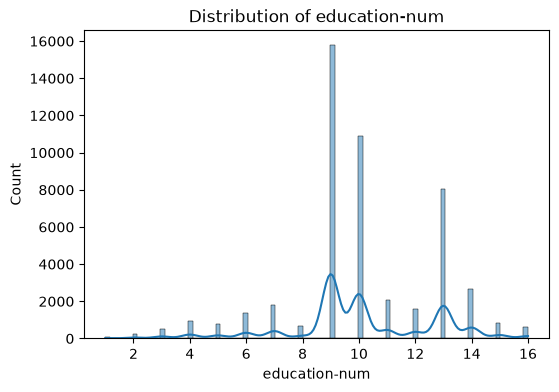

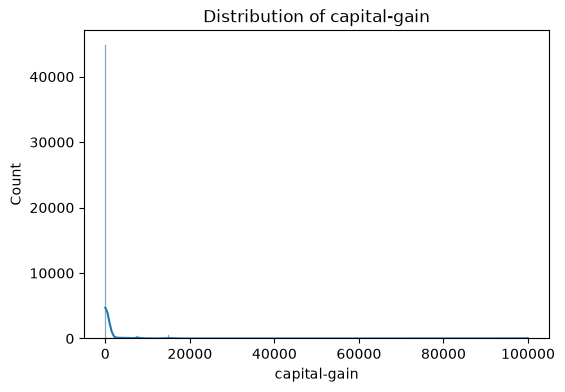

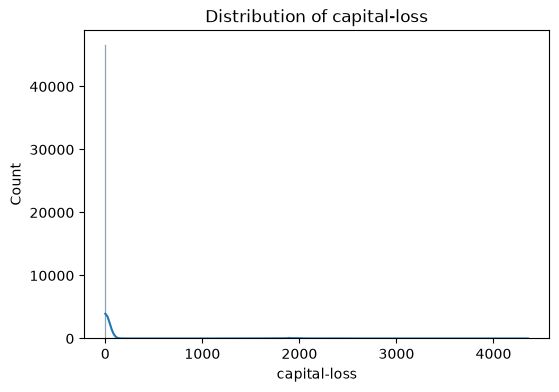

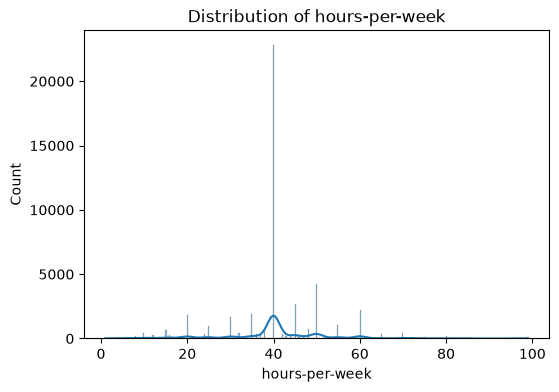

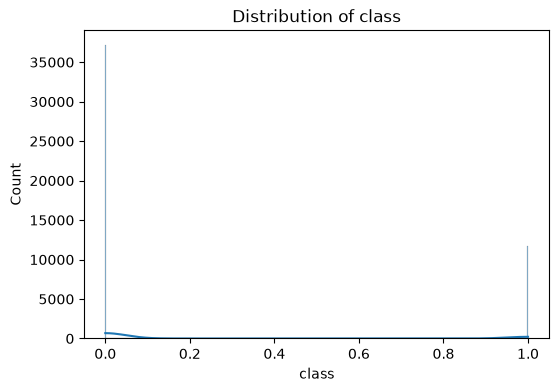

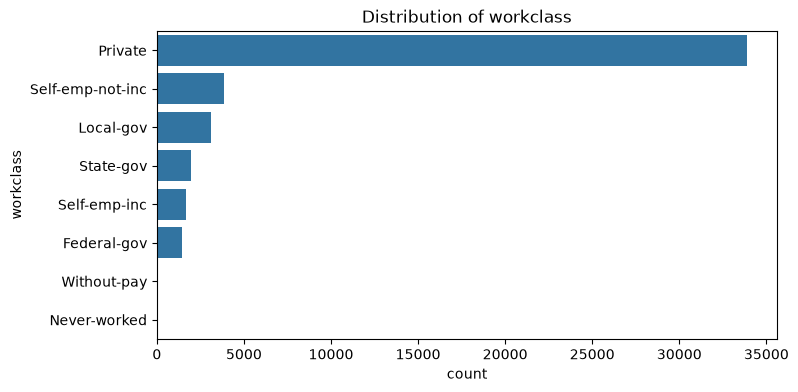

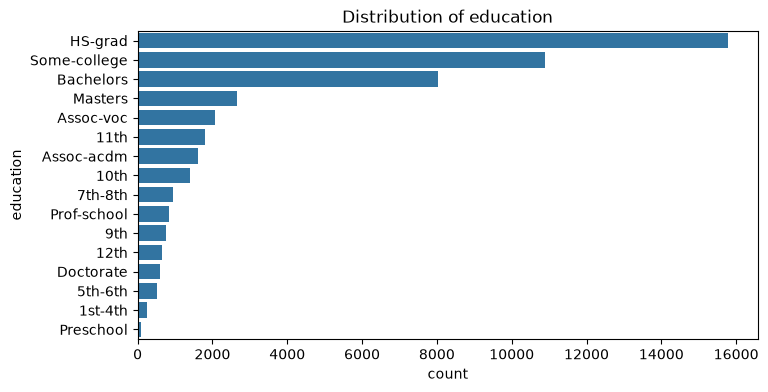

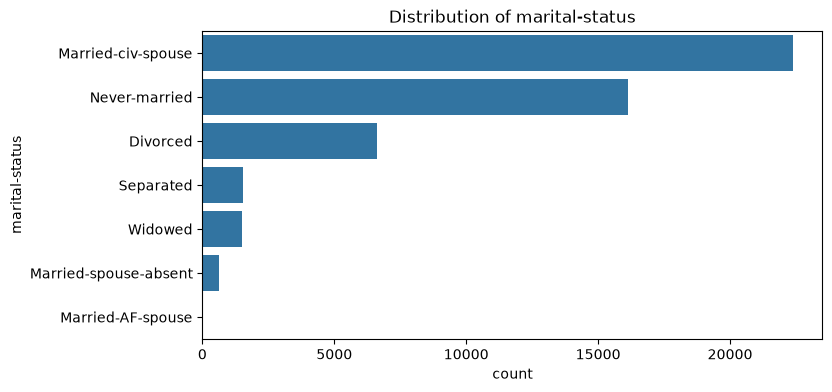

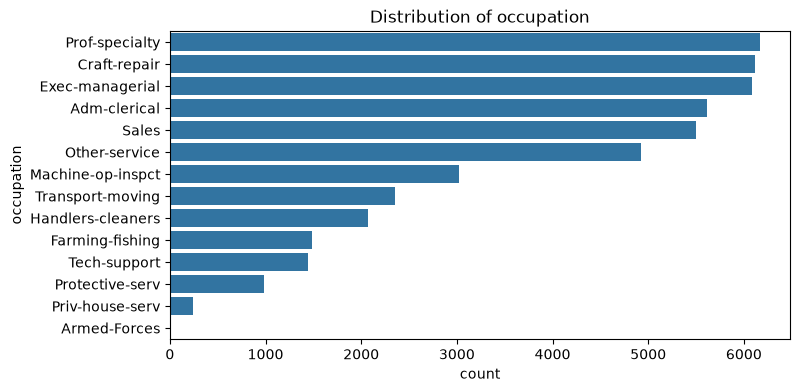

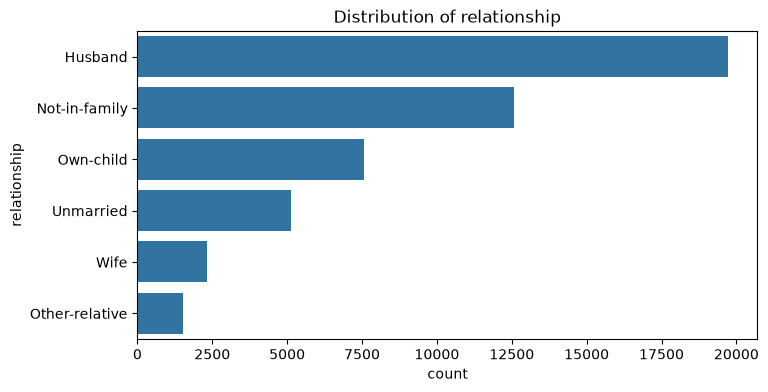

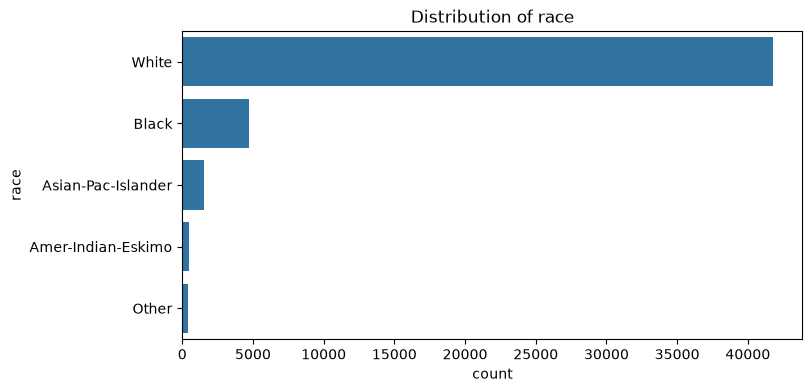

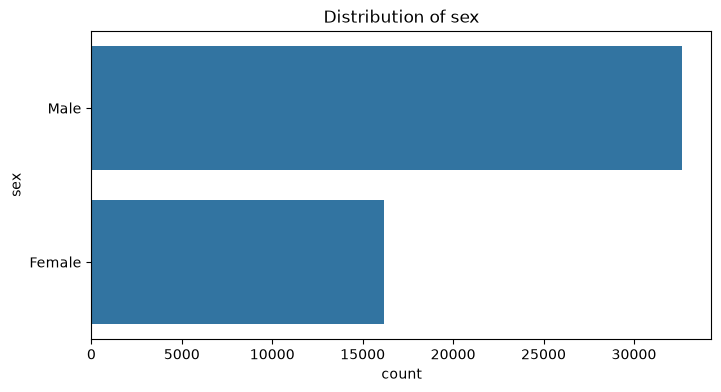

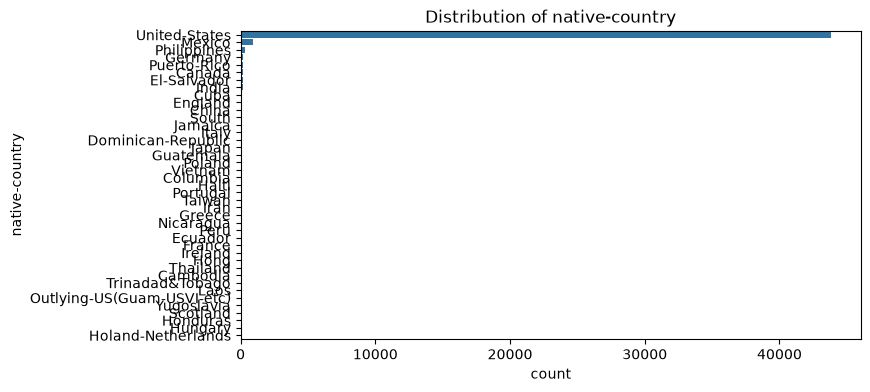

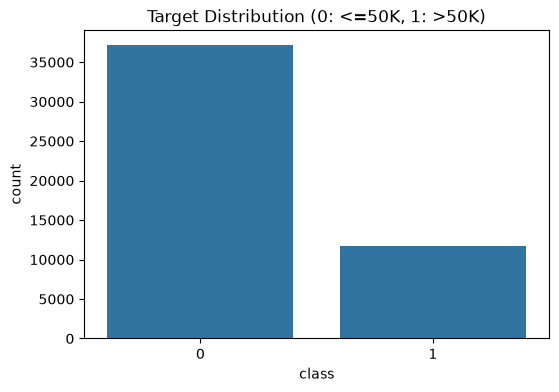

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Convert target labels to 0 and 1
df['class'] = df['class'].str.strip().map({'<=50K': 0, '>50K': 1})
# Display dataset shape, data types, and non-null counts
print("Dataset Shape:", df.shape)
print("\n--- Data Types & Info ---")
df.info()

# Summary statistics for numerical features
print("\n--- Numerical Summary ---")
display(df.describe().T)

# Summary statistics for categorical features
print("\n--- Categorical Summary ---")
display(df.describe(include=['object', 'category']).T)

# Replace string '?' placeholders with NaN if present
df.replace('?', np.nan, inplace=True)

num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.show()

# Plot target distribution for summary table
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df)
plt.title("Target Distribution (0: <=50K, 1: >50K)")
plt.show()



,count,% of total
class,,
<=50K,37155,76.07
>50K,11687,23.93


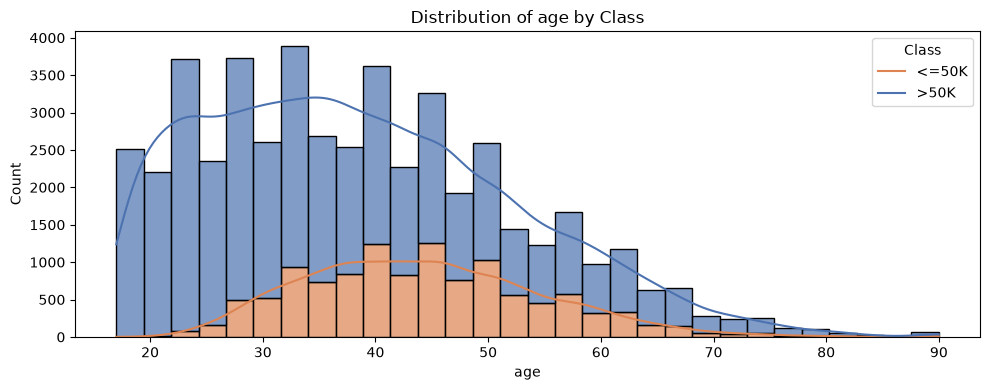

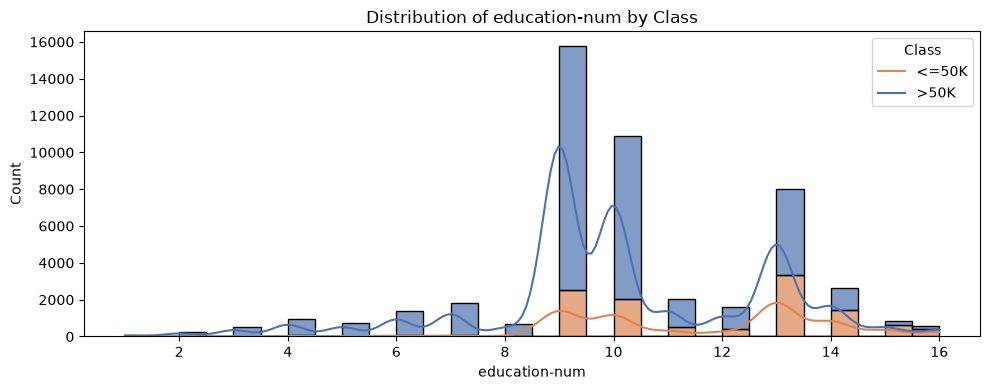

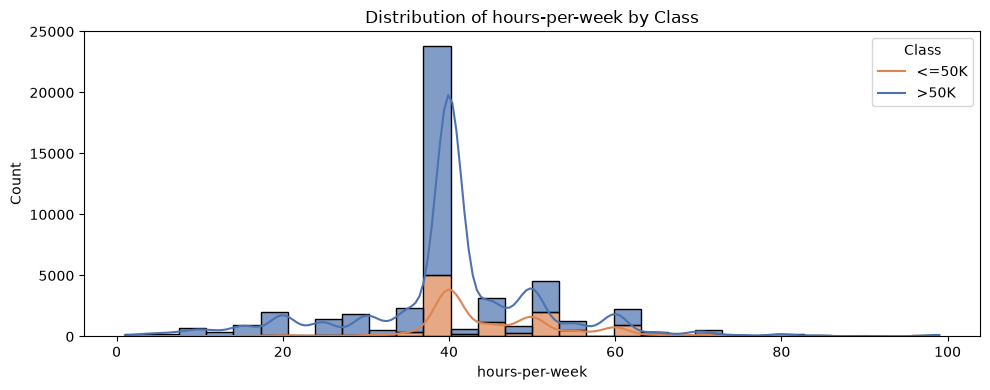

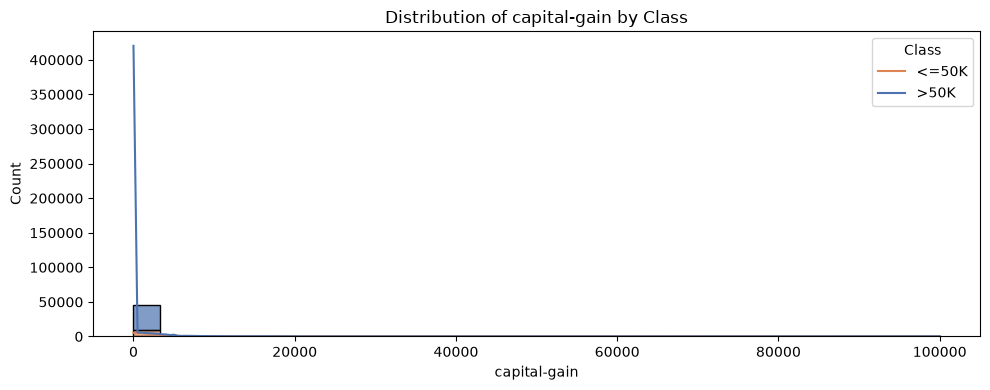

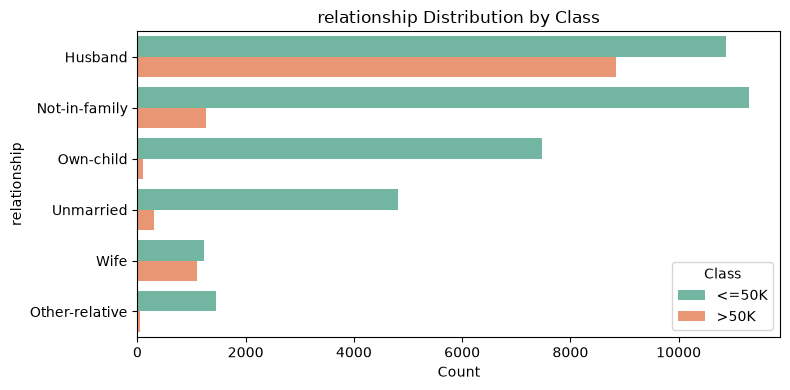

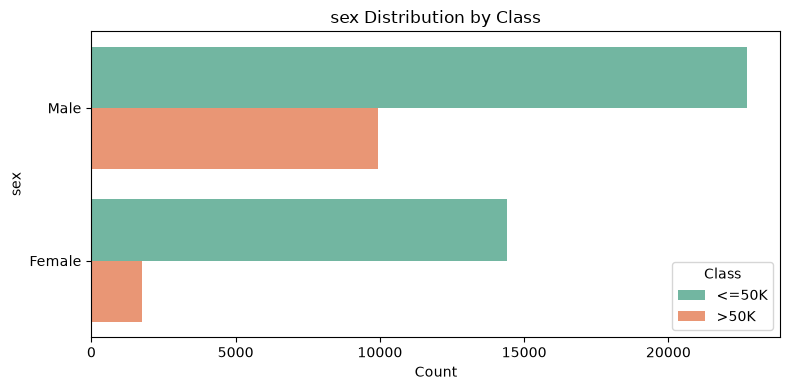

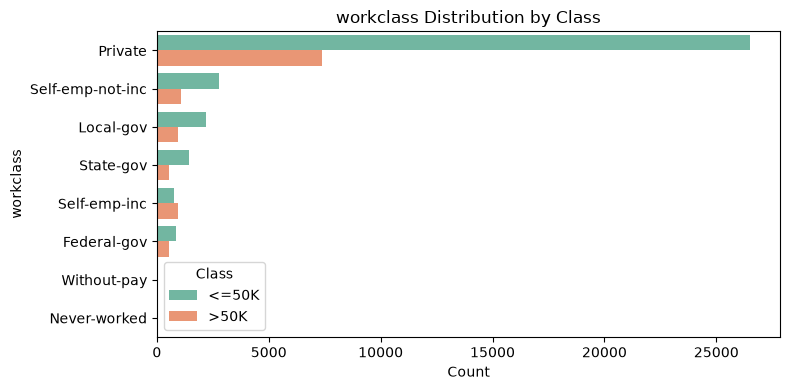

In [20]:
# Class summary table
class_summary = (
    df['class']
    .value_counts()
    .rename(index={0: '<=50K', 1: '>50K'})
    .to_frame(name='count')
)

class_summary['% of total'] = (class_summary['count'] / class_summary['count'].sum() * 100).round(2)
display(class_summary)

# Notable feature distributions by class
for col in ['age', 'education-num', 'hours-per-week', 'capital-gain']:
    if col not in df.columns:
        continue

    plt.figure(figsize=(10, 4))
    sns.histplot(
        data=df,
        x=col,
        hue='class',
        bins=30,
        kde=True,
        multiple='stack',
        palette='deep',
        alpha=0.7
    )
    plt.title(f"Distribution of {col} by Class")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title='Class', labels=['<=50K', '>50K'])
    plt.tight_layout()
    plt.show()

# Optional categorical view for business interpretation
for col in ['relationship', 'sex', 'workclass']:
    if col not in df.columns:
        continue

    plt.figure(figsize=(8, 4))
    sns.countplot(
        data=df,
        y=col,
        hue='class',
        order=df[col].value_counts().index,
        palette='Set2'
    )
    plt.title(f"{col} Distribution by Class")
    plt.ylabel(col)
    plt.xlabel("Count")
    plt.legend(title='Class', labels=['<=50K', '>50K'])
    plt.tight_layout()
    plt.show()

# Task 3

In [21]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['class'])
y = df['class']

# Stratified Hold-out Test Set (20%)
X_train_dev, X_test, y_train_dev, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Dev set (10% of total data = 12.5% of train_dev)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_dev, y_train_dev, test_size=0.125, random_state=42, stratify=y_train_dev
)

print(f"Train set: {X_train.shape[0]} | Dev set: {X_dev.shape[0]} | Test set: {X_test.shape[0]}")

Train set: 34188 | Dev set: 4885 | Test set: 9769


Text Explanation: "A hold-out test set is essential to provide an unbiased final estimate of model performance on unseen, real-world data. If the test set is touched or used during hyperparameter tuning, the model indirectly fits to its specific patterns, leading to data leakage and overly optimistic performance metrics that fail in production."

# Task 4

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay

MajorityModel = DummyClassifier(strategy='most_frequent')
MajorityModel.fit(X_train, y_train)

MajorityPred = MajorityModel.predict(X_test)
MajorityProb = MajorityModel.predict_proba(X_test)[:, 1]

# Single-Feature Rule Baseline: education-num >= 13
# Rationale: Higher education levels are generally associated with higher income,
# making education-num a reasonable simple feature for predicting income >50K.
# This rule is intentionally simple and provides a baseline for comparison with
# more advanced machine learning models.

RulePred = (X_test['education-num'] >= 13).astype(int)
RuleScore = X_test['education-num']

def EvaluateModel(YTrue, YPred, YScore):
    return {
        'Accuracy': accuracy_score(YTrue, YPred),
        'Precision': precision_score(YTrue, YPred, zero_division=0),
        'Recall': recall_score(YTrue, YPred, zero_division=0),
        'F1': f1_score(YTrue, YPred, zero_division=0),
        'ROC AUC': roc_auc_score(YTrue, YScore),
        'PR AUC': average_precision_score(YTrue, YScore)
    }

MajorityResults = EvaluateModel(
    y_test,
    MajorityPred,
    MajorityProb
)

RuleResults = EvaluateModel(
    y_test,
    RulePred,
    RuleScore
)

MetricsTable = pd.DataFrame(
    [MajorityResults, RuleResults],
    index=['Majority Class', 'Education Rule']
)

MetricsTable

,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
Majority Class,0.760672,0.000000,0.000000,0.000000,0.500000,0.239328
Education Rule,0.752994,0.484368,0.497006,0.490606,0.718863,0.444258


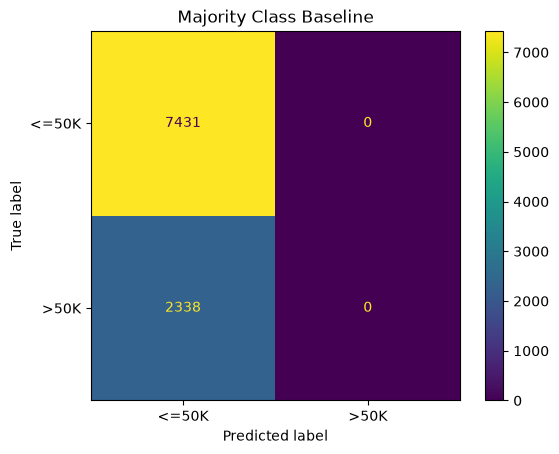

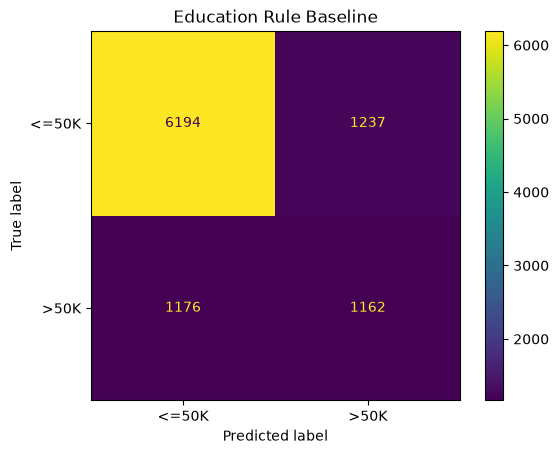

In [23]:
MajorityCM = confusion_matrix(y_test, MajorityPred)

ConfusionMatrixDisplay(
    confusion_matrix=MajorityCM,
    display_labels=['<=50K', '>50K']
).plot()

plt.title('Majority Class Baseline')
plt.show()

RuleCM = confusion_matrix(y_test, RulePred)

ConfusionMatrixDisplay(
    confusion_matrix=RuleCM,
    display_labels=['<=50K', '>50K']
).plot()

plt.title('Education Rule Baseline')
plt.show()

The Education Rule baseline performs better than the Majority Class baseline for identifying the positive >50K class. Although the Majority Class baseline achieves slightly higher accuracy (76.07%), it predicts every individual as <=50K, resulting in zero precision, recall, and F1 for the positive class. The Education Rule achieves an F1 score of 0.491, ROC AUC of 0.719, and PR AUC of 0.444, showing that education level provides useful predictive information. A real supervised model should substantially outperform this baseline, with at least a 5–10 percentage-point improvement in F1 (approximately 0.54–0.59 or higher) being a reasonable minimum to consider the model meaningfully useful.

# Task 5

In [24]:
ErrorAnalysis = X_test.copy()
ErrorAnalysis['Actual'] = y_test
ErrorAnalysis['Predicted'] = RulePred

FalsePositives = ErrorAnalysis[
    (ErrorAnalysis['Actual'] == 0) &
    (ErrorAnalysis['Predicted'] == 1)
]

FalseNegatives = ErrorAnalysis[
    (ErrorAnalysis['Actual'] == 1) &
    (ErrorAnalysis['Predicted'] == 0)
]

print("False Positives:", len(FalsePositives))
print("False Negatives:", len(FalseNegatives))

False Positives: 1237
False Negatives: 1176


In [25]:
print("Sample False Positives:")
display(FalsePositives.head(10))

print("Sample False Negatives:")
display(FalseNegatives.head(10))

Sample False Positives:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Actual,Predicted
38546,42,Private,269028,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,France,0,1
18199,25,Local-gov,125863,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Male,0,0,35,United-States,0,1
2271,24,Self-emp-inc,197496,Bachelors,13,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0,1
35730,37,Private,225504,Masters,14,Never-married,Sales,Not-in-family,White,Male,0,0,50,United-States,0,1
44616,35,Private,198341,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Asian-Pac-Islander,Male,0,0,40,NaN,0,1
7541,23,Private,107882,Bachelors,13,Never-married,Tech-support,Own-child,White,Female,0,0,50,United-States,0,1
42512,26,Private,29957,Masters,14,Never-married,Tech-support,Other-relative,White,Male,0,0,25,United-States,0,1
5805,53,Private,107096,Bachelors,13,Never-married,Sales,Unmarried,White,Male,0,1669,50,United-States,0,1
36308,40,Private,105936,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,40,United-States,0,1
38118,40,Self-emp-not-inc,282678,Masters,14,Separated,Exec-managerial,Unmarried,White,Female,0,0,20,United-States,0,1


Sample False Negatives:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Actual,Predicted
31692,47,Local-gov,352614,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1,0
11488,38,Private,414991,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,1,0
33956,68,Self-emp-not-inc,133736,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,20051,0,40,United-States,1,0
45549,26,Local-gov,72594,Some-college,10,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,55,United-States,1,0
9863,56,Private,442116,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,54,United-States,1,0
30035,42,Private,107276,Some-college,10,Never-married,Exec-managerial,Not-in-family,White,Female,0,2444,40,United-States,1,0
29836,43,Private,191814,Assoc-acdm,12,Married-civ-spouse,Sales,Husband,White,Male,7688,0,50,United-States,1,0
41420,50,Private,185407,Assoc-voc,11,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,38,United-States,1,0
17615,51,Private,146767,Assoc-voc,11,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,1,0
32445,57,Self-emp-inc,244605,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,50,United-States,1,0


## Task 5: Initial Error Analysis & Next Steps

From the sampled false positives and false negatives, the main pattern is that the education rule captures the obvious high-income signal, but it misses many cases where income is driven by work intensity, occupation type, or other interacting factors. The false positives are often individuals with good education or more professional-looking profiles who still fall below the >50K threshold, which suggests that education alone is not enough to distinguish high earners from lower earners. The false negatives are often younger individuals, people with large numbers of hours worked per week, or workers who do not fit the standard educational path but still earn above $50K. This indicates that the model is learning a narrow rule and is missing complex patterns that require more information and better feature engineering.

### Concrete Data / Feature Issues to Fix Tomorrow

1. Missing and inconsistent categorical values: Handle missing entries in workclass, occupation, and native-country consistently and map placeholders to a clear Unknown category.
2. High-cardinality categorical encoding: Apply one-hot encoding to nominal features such as relationship, race, and sex, while using ordinal or target encoding for occupation and native-country.
3. Highly skewed numerical features: Apply a logarithmic transformation such as log(x + 1) to capital-gain and capital-loss to reduce the effect of outliers and long tails.
4. Continuous feature scaling: Standardize or robust-scale age, fnlwgt, and hours-per-week so that features with larger magnitudes do not dominate model training.
5. Feature engineering for interaction effects: Create new variables such as age × hours-per-week, net capital (capital-gain - capital-loss), and binary indicators for non-zero capital activity.
6. Rare category grouping: Combine low-frequency categories in occupation and native-country into broader groups to reduce sparsity and improve generalization.

The primary metric to optimize for the rest of the week is F1 score, not accuracy. Accuracy is misleading because the dataset is imbalanced: the majority baseline reaches 76.07% accuracy simply by predicting every observation as <=50K, but it achieves 0.00 precision, 0.00 recall, and 0.00 F1 for the positive class. The education rule baseline is better, with an F1 score of 0.491 and ROC AUC of 0.719, but it still misses many true >50K cases. Since the business goal is to identify high-income prospects while avoiding wasted outreach, F1 is the correct metric because it balances precision and recall and directly reflects how well the model is finding the positive class without sacrificing too much quality.